
## [실습] ETF 추천 시스템 개선

### 필수 과제
1. **에러 처리 개선**: execute_query 함수에 더 상세한 에러 처리 로직 추가
2. **테스트 검증**: 추천 결과의 필수 필드 검증 로직 추가

### 선택 과제
1. **랭킹 알고리즘 개선**: 사용자 프로필에 따른 가중치 조정 로직 추가
3. **프롬프트 개선**: Text2SQL 프롬프트의 정확도 향상


`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import warnings
warnings.filterwarnings('ignore')

`(3) SQLite DB`

In [3]:
from langchain_community.utilities import SQLDatabase

# ETF 데이터베이스 연결
db = SQLDatabase.from_uri(
    "sqlite:///etf_database.db",
    # ignore_tables=['ETFsInfo']
    )

# 사용 가능한 테이블 목록 
print(db.dialect)
print(db.get_usable_table_names())
etfs = db.run("SELECT * FROM ETFs LIMIT 5;")

for etf in eval(etfs):
    print(etf)

sqlite
['ETFs', 'ETFsInfo']
('466400', '1Q 25-08 회사채(A+이상)액티브', '2023/09/19', '채권-회사채-단기', '하나자산운용', 4.52, 'KIS 2025-08만기형 크레딧 A+이상 지수(총수익)', 0.11, 111916276404.0, 0.03, '매우낮음', '실물(액티브)', 0.1, '배당소득세(보유기간과세)')
('491610', '1Q CD금리액티브(합성)', '2024/09/24', '기타', '하나자산운용', 0.0, 'KIS 하나 CD금리 총수익지수', 0.05, 316206006696.0, 0.02, '매우낮음', '합성(액티브)', 0.02, '배당소득세(보유기간과세)')
('451060', '1Q K200액티브', '2023/01/31', '주식-시장대표', '하나자산운용', -3.66, '코스피 200', 0.77, 99754348820.0, -0.01, '높음', '실물(액티브)', 0.18, '배당소득세(보유기간과세)')
('463290', '1Q 단기금융채액티브', '2023/08/03', '채권-혼합-단기', '하나자산운용', 4.01, 'MK 머니마켓 지수(총수익)', 0.05, 252717462257.0, 0.0, '매우낮음', '실물(액티브)', 0.08, '배당소득세(보유기간과세)')
('479080', '1Q 머니마켓액티브', '2024/04/02', '채권-혼합-단기', '하나자산운용', 0.0, 'KIS-하나 MMF 지수(총수익)', 0.06, 308255065986.0, -0.01, '매우낮음', '실물(액티브)', 0.05, '배당소득세(보유기간과세)')


`(4) SQL QA Chain`

-  DB 테이블에서 고유명사 추출

In [4]:
import ast
import re

def query_as_list(db, query):
    res = db.run(query)
    res = [el for sub in ast.literal_eval(res) for el in sub if el]
    res = [re.sub(r"\b\d+\b", "", string).strip() for string in res]
    return list(set(res))


etfs = query_as_list(db, "SELECT DISTINCT 종목명 FROM ETFs")
fund_managers = query_as_list(db, "SELECT DISTINCT 운용사 FROM ETFs")
underlying_assets = query_as_list(db, "SELECT DISTINCT 기초지수 FROM ETFs")

print("ETFs:", len(etfs))
print("Fund Managers:", len(fund_managers))
print("Underlying Assets:", len(underlying_assets))

print(etfs[:5])
print(fund_managers[:5])
print(underlying_assets[:5])

ETFs: 925
Fund Managers: 26
Underlying Assets: 665
['TIGER 미국나스닥100레버리지(합성)', 'ACE 미국나스닥100', 'SOL 종합채권(AA-이상)액티브', 'RISE', 'TIGER 미국테크TOP10채권혼합']
['마이다스에셋', '하나자산운용', '아이비케이자산운용', '삼성자산운용', '엔에이치아문디자산운용']
['FnGuide Low Vol 지수', 'KAP 국채30년 TR 지수(총수익)', 'FnGuide 의료기기소부장지수(PR)', 'Solactive 미국천연가스인프라 PR 지수', 'DAX Index(PR)']


- 고유명사를 벡터스토어에 저장

In [ ]:
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

# 임베딩 모델 생성
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# 임베딩 벡터 저장소 생성
vector_store = InMemoryVectorStore(embeddings)

from langchain_core.documents import Document

# 1. 메타데이터(타입/분류)를 포함하는 Document 객체 생성
documents = []

# ETF 종목명 추가
for etf in etfs:
    documents.append(
        Document(
            page_content=etf,
            metadata={"type": "종목명"}
        )
    )

# 운용사 추가
for manager in fund_managers:
    documents.append(
        Document(
            page_content=manager,
            metadata={"type": "운용사"}
        )
    )

# 기초지수 추가
for asset in underlying_assets:
    documents.append(
        Document(
            page_content=asset,
            metadata={"type": "기초지수"}
        )
    )

# 2. Document 형식을 벡터 저장소에 저장
_ = vector_store.add_documents(documents)
vector_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

In [6]:
from typing import Optional, Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

# 1. LLM이 출력할 구조 정의
class SearchQueryAnalyzer(BaseModel):
    query: str = Field(
        description="벡터 검색에 사용할 핵심 검색어 또는 고유명사 (예: '삼성', '다우존스', '미래에셋')"
    )
    filter_type: Optional[Literal["종목명", "운용사", "기초지수"]] = Field(
        default=None,
        description="사용자 질문에서 특정 타입의 대상을 검색하고자 하는 의도가 명확할 때만 지정합니다. (예: '삼성 운용사' -> '운용사', '코스피 지수 관련' -> '기초지수')"
    )

# 2. 구조화된 출력을 지원하는 LLM 선언
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
structured_analyzer = llm.with_structured_output(SearchQueryAnalyzer)
# 3. 자연어 질문 분석 및 동적 필터 적용 검색 함수 정의
def search_vector_store(user_question: str):
    # LLM을 통해 질문 분석
    analysis: SearchQueryAnalyzer = structured_analyzer.invoke(user_question)
    print(f"질문 분석 결과: 쿼리='{analysis.query}', 필터='{analysis.filter_type}'")
    
    # 동적 필터 딕셔너리 생성
    # InMemoryVectorStore에 맞는 동적 필터 구현 예시
    if analysis.filter_type:
        # 각 Document의 metadata['type']과 추출된 filter_type을 동적으로 비교하는 람다 함수 전달
        search_filter = lambda doc: doc.metadata.get("type") == analysis.filter_type
    else:
        search_filter = None

        
    # 벡터 저장소 검색 실행
    results = vector_store.similarity_search(
        query=analysis.query,
        k=5,
        filter=search_filter
    )
    
    return results


In [7]:
# --- 테스트 예시 ---
# 1) 필터가 작동하는 경우 (운용사)
print("--- 테스트 1 ---")
results_1 = search_vector_store("삼성자산 운용사에서 나온 상품 알려줘")
for doc in results_1:
    print(f"[{doc.metadata['type']}] {doc.page_content}")

# 2) 필터가 작동하는 경우 (기초지수)
print("\n--- 테스트 2 ---")
results_2 = search_vector_store("코스피 지수 관련 ETF 검색해줘")
for doc in results_2:
    print(f"[{doc.metadata['type']}] {doc.page_content}")

# 3) 특정 분류가 애매하여 필터 없이 전체 검색하는 경우
print("\n--- 테스트 3 ---")
results_3 = search_vector_store("미래에셋 타이거는 뭐야?")
for doc in results_3:
    print(f"[{doc.metadata['type']}] {doc.page_content}")

--- 테스트 1 ---
질문 분석 결과: 쿼리='삼성자산 운용사에서 나온 상품', 필터='운용사'
[운용사] 삼성자산운용
[운용사] 삼성액티브자산운용
[운용사] 신한자산운용
[운용사] 우리자산운용
[운용사] 흥국자산운용

--- 테스트 2 ---
질문 분석 결과: 쿼리='코스피 지수 관련 ETF', 필터='None'
[기초지수] 코스피
[기초지수] 코스피 우선주 지수
[기초지수] 코스피  ESG 지수
[기초지수] 코스피  금융
[기초지수] 코스피  Top  지수

--- 테스트 3 ---
질문 분석 결과: 쿼리='미래에셋 타이거는 뭐야?', 필터='운용사'
[운용사] 미래에셋자산운용
[운용사] 마이다스에셋
[운용사] 유리에셋
[운용사] 트러스톤자산운용
[운용사] 에셋플러스자산운용


- 고유명사를 키워드 검색으로 적용

In [8]:
### kiwipiepy 토크나이저 함수 정의

from kiwipiepy import Kiwi
import re

# Kiwi 토크나이저 초기화
kiwi = Kiwi()

def korean_tokenizer(text):
    """kiwipiepy를 사용한 한국어 토크나이징 함수"""
    # 기본 전처리
    text = re.sub(r'[^\w\s]', '', text)  # 특수문자 제거
    text = text.lower()  # 소문자 변환
    
    # Kiwi로 형태소 분석
    tokens = kiwi.tokenize(text)
    
    # 명사, 형용사, 동사, 외국어, 한자 등 필터링 (선별 추출)
    filtered_tokens = []
    for token in tokens:
        if token.tag in ['NNG', 'NNP', 'VA', 'VV', 'SL', 'SH']:  # 일반명사, 고유명사, 형용사, 동사, 외국어, 한자
            filtered_tokens.append(token.form)
    
    return filtered_tokens if filtered_tokens else [token.form for token in tokens]

# 테스트
print(korean_tokenizer("다우존스 관련 ETF는 무엇인가요?"))


['다우존스', '관련', 'etf']


In [9]:
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document

# 고유명사를 Document 객체로 변환
proper_noun_docs = [Document(page_content=name) for name in etfs + fund_managers + underlying_assets]

# BM25 검색기 생성 (Kiwi 토크나이저 적용)
bm25_retriever = BM25Retriever.from_documents(
    proper_noun_docs,
    preprocess_func=korean_tokenizer,
    k=20,
)
print(f"BM25 검색기 생성 완료: {len(proper_noun_docs)}개 문서 등록")

# 테스트
query = "다우존스 관련 ETF는 무엇인가요?"
results = bm25_retriever.invoke(query)
print(f"\nQuery: {query}")
print("-" * 40)
for result in results:
    print(f"Document: {result.page_content}")

BM25 검색기 생성 완료: 1616개 문서 등록

Query: 다우존스 관련 ETF는 무엇인가요?
----------------------------------------
Document: TIGER 미국다우존스30
Document: KRX 나스닥  ETF 선물지수
Document: TIGER 미국나스닥100ETF선물
Document: KOSEF 미국ETF산업STOXX
Document: 다우존스 인터넷 종합지수
Document: SOL 미국배당다우존스
Document: KODEX 미국배당다우존스
Document: TIGER 미국배당다우존스
Document: ACE 미국배당다우존스
Document: STOXX USA ETF Industry Index (KRW)
Document: KODEX 미국ETF산업Top10 Indxx
Document: SOL 미국배당다우존스TR
Document: SOL 미국배당다우존스(H)
Document: KODEX 대만테크고배당다우존스
Document: Indxx US ETF Industry Top10 Index(Price Return)
Document: PLUS 미국다우존스고배당주(합성 H)
Document: KRX 다우존스 미국배당국채 혼합지수
Document: TIGER 미국배당다우존스타겟커버드콜1호
Document: TIGER 미국배당다우존스타겟커버드콜2호
Document: KODEX 미국배당다우존스타겟커버드콜


In [10]:
### 하이브리드 앙상블 리트리버 생성
from langchain_classic.retrievers import EnsembleRetriever

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, vector_retriever],
    weights=[0.5, 0.5]
)

# 테스트
query = "다우존스 관련 ETF는 무엇인가요?"
results = ensemble_retriever.invoke(query)
print(f"Query: {query}")
print("-" * 40)
for result in results:
    print(f"Document: {result.page_content}")

Query: 다우존스 관련 ETF는 무엇인가요?
----------------------------------------
Document: 다우존스 인터넷 종합지수
Document: KODEX 미국배당다우존스
Document: SOL 미국배당다우존스
Document: ACE 미국배당다우존스
Document: KODEX 대만테크고배당다우존스
Document: SOL 미국배당다우존스(H)
Document: KRX 나스닥  ETF 선물지수
Document: TIGER 미국다우존스30
Document: SOL 미국배당다우존스TR
Document: TIGER 미국배당다우존스
Document: KRX 다우존스 미국배당국채 혼합지수
Document: KODEX 미국ETF산업Top10 Indxx
Document: PLUS 미국다우존스고배당주(합성 H)
Document: KODEX 미국배당다우존스타겟커버드콜
Document: TIGER 미국나스닥100ETF선물
Document: KOSEF 미국ETF산업STOXX
Document: STOXX USA ETF Industry Index (KRW)
Document: KODEX iShares미국인플레이션국채액티브
Document: KODEX iShares미국투자등급회사채액티브
Document: Indxx US ETF Industry Top10 Index(Price Return)
Document: Dow Jones U.S Select Dividend Index(시장가격지수)
Document: Dow Jones Target  Index (Total Return)
Document: TIGER 미국배당다우존스타겟커버드콜1호
Document: KODEX iShares미국하이일드액티브
Document: TIGER 미국배당다우존스타겟커버드콜2호
Document: KODEX 미국테크1조달러기업포커스


- 검색 결과 변환하는 함수

In [11]:
from langchain_core.tools import tool

# 검색 도구 생성 - 하이브리드 검색기 사용
@tool("search_proper_nouns")
def entity_retriever_tool(query: str) -> str:
    """
    Use to look up values to filter on. Input is an approximate spelling 
    of the proper noun, output is valid proper nouns. Use the noun most 
    similar to the search.
    """
    docs = ensemble_retriever.invoke(query)
    return "\n\n".join([doc.page_content for doc in docs])

# 검색 도구 테스트
print(entity_retriever_tool.invoke("다우존스 관련 ETF는 무엇인가요?"))

다우존스 인터넷 종합지수

KODEX 미국배당다우존스

SOL 미국배당다우존스

ACE 미국배당다우존스

KODEX 대만테크고배당다우존스

SOL 미국배당다우존스(H)

KRX 나스닥  ETF 선물지수

TIGER 미국다우존스30

SOL 미국배당다우존스TR

TIGER 미국배당다우존스

KRX 다우존스 미국배당국채 혼합지수

KODEX 미국ETF산업Top10 Indxx

PLUS 미국다우존스고배당주(합성 H)

KODEX 미국배당다우존스타겟커버드콜

TIGER 미국나스닥100ETF선물

KOSEF 미국ETF산업STOXX

STOXX USA ETF Industry Index (KRW)

KODEX iShares미국인플레이션국채액티브

KODEX iShares미국투자등급회사채액티브

Indxx US ETF Industry Top10 Index(Price Return)

Dow Jones U.S Select Dividend Index(시장가격지수)

Dow Jones Target  Index (Total Return)

TIGER 미국배당다우존스타겟커버드콜1호

KODEX iShares미국하이일드액티브

TIGER 미국배당다우존스타겟커버드콜2호

KODEX 미국테크1조달러기업포커스


**에러 처리 개선**: execute_query 함수에 더 상세한 에러 처리 로직 추가

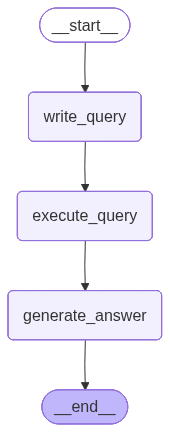

In [91]:
from typing import Annotated, TypedDict, List, Dict, Any 
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import QuerySQLDatabaseTool
from langgraph.graph import START, StateGraph 
from IPython.display import Image, display
from langchain_community.tools.sql_database.tool import QuerySQLDatabaseTool
from sqlalchemy.exc import OperationalError, ProgrammingError
# 상태 정보를 저장하는 State 클래스
class State(TypedDict):
    question: str      # 입력 질문
    user_profile: str  # 추가: 동적 가중치 및 추천 설명에 쓰일 유저 성향 데이터
    query: str         # 생성된 쿼리
    result: str        # 쿼리 결과
    candidates: str    # 추가: DB에서 조회된 추출된 후보 ETF 리스트
    rankings: List[Dict[str, Any]]  # 🌟 이제 에러 없이 정상 작동합니다!
    applied_weights: Dict[str, int] # 선택: 어떤 가중치가 적용되었는지 추적 로그용
    answer: str        # 생성된 최종 답변 (마크다운 보고서 등)
    final_answer: Dict[str, Any]
# llm 모델 생성
llm = ChatOpenAI(model="gpt-4.1-mini")

# sql 쿼리 생성 프롬프트 
template = """
Given an input question, create a syntactically correct {dialect} query to run to help find the answer. Unless the user specifies in his question a specific number of examples they wish to obtain, always limit your query to at most {top_k} results. You can order the results by a relevant column to return the most interesting examples in the database.

Never query for all the columns from a specific table, only ask for a the few relevant columns given the question.

Pay attention to use only the column names that you can see in the schema description. Be careful to not query for columns that do not exist. Also, pay attention to which column is in which table.

Only use the following tables:
{table_info}

Entity names and their relationships to consider:
{entity_info}

## Matching Guidelines
- Use exact matches when comparing entity names
- Check for historical name variations if available
- Apply case-sensitive matching for official names
- Handle both Korean and English entity names when present

Question: {input}
"""
query_prompt_template = ChatPromptTemplate.from_template(template)

# SQL 쿼리 생성 함수
class QueryOutput(TypedDict):
    """Generated SQL query."""
    query: Annotated[str, ..., "Syntactically valid SQL query."]
def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "input": state["question"],
            "entity_info": entity_retriever_tool.invoke(state["question"]),
        }
    )
    
    # 🌟 1. 쿼리가 끊기지 않도록 대용량 토큰(max_tokens)과 결정론적 출력(temperature=0)을 세팅한 LLM을 준비합니다.
    # 기존 llm이 제공한 기본 설정을 유지하면서 파라미터만 바인딩합니다.
    strict_llm = llm.bind(temperature=0, max_tokens=2048)
    
    # 구조화된 출력 적용
    structured_llm = strict_llm.with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)
    
    # 🌟 2. Pydantic 결과물인 경우 객체(.query) 또는 딕셔너리(["query"]) 형태 모두 안전하게 대응합니다.
    if hasattr(result, "query"):
        generated_query = result.query
    elif isinstance(result, dict):
        generated_query = result.get("query", "")
    else:
        generated_query = str(result)
        
    return {"query": generated_query}
# SQL 쿼리 실행 함수


def execute_query(state: State):
    """
    상세한 에러 처리가 포함된 SQL 쿼리 실행 함수.
    결과를 state['candidates']에 저장하여 다음 노드(rank_etfs)와 연동합니다.
    """
    # 1. 사전 검증: state에 'query' 키가 없거나 비어있는 경우
    query = state.get("query")
    if not query or not isinstance(query, str) or not query.strip():
        return {
            "candidates": "Error: State에 유효한 'query'가 없습니다. 문자열 형태의 SQL 쿼리가 필요합니다.", # 🌟 변경
            "error_type": "ValidationError"
        }
    
    try:
        # 쿼리 실행 툴 초기화 및 호출
        execute_query_tool = QuerySQLDatabaseTool(db=db)
        response = execute_query_tool.invoke(query)
        
        # 툴 내부에서 에러 문자열을 반환하는 경우가 있으므로 체크
        if "Error:" in str(response) or "Exception" in str(response):
            return {
                "candidates": str(response), # 🌟 변경
                "error_type": "DatabaseError"
            }
            
        return {
            "candidates": str(response), # 🌟 변경
            "error_type": None
        }
        
    except ProgrammingError as e:
        # SQL 문법 오류 등
        error_msg = f"SQL Syntax/Schema Error: {str(e.orig)}"
        return {
            "candidates": f"쿼리 실행 실패. 문법을 확인하세요.\n{error_msg}", # 🌟 변경
            "error_type": "ProgrammingError"
        }
        
    except OperationalError as e:
        # DB 연결 문제 등
        error_msg = f"Database Connection Error: {str(e.orig)}"
        return {
            "candidates": f"데이터베이스 연결 실패.\n{error_msg}", # 🌟 변경
            "error_type": "OperationalError"
        }
        
    except Exception as e:
        # 그 외 예상치 못한 모든 예외 처리
        return {
            "candidates": f"Unexpected Error: {str(e)}", # 🌟 변경
            "error_type": "UnknownError"
        }

# 답변 생성 함수
def generate_answer(state: State):
    """Answer question using retrieved information as context."""
    # 🌟 'result' 대신 안전하게 'candidates' 데이터를 가져옵니다.
    db_result = state.get("candidates") or state.get("result") or ""
    
    prompt = (
        "Given the following user question, corresponding SQL query, "
        "and SQL result, answer the user question.\n\n"
        f'Question: {state["question"]}\n'
        f'SQL Query: {state["query"]}\n'
        f'SQL Result: {db_result}'  # 🌟 안전하게 확보한 변수로 매핑
    )
    response = llm.invoke(prompt)
    return {"answer": response.content}

# 상태 그래프 생성
graph_builder = StateGraph(State)

graph_builder.add_node("write_query", write_query)
graph_builder.add_node("execute_query", execute_query)
graph_builder.add_node("generate_answer", generate_answer)

graph_builder.add_edge(START, "write_query")
graph_builder.add_edge("write_query", "execute_query")
graph_builder.add_edge("execute_query", "generate_answer")  
graph = graph_builder.compile()

# 상태 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
# 고유명사를 사용하는 쿼리 테스트 - 운용사
for step in graph.stream(
    {"question": "케이비에서 운용하는 헬스케어 ETF는 무엇인가요?"}, stream_mode="updates"
):
    print(step)

{'write_query': {'query': "SELECT 종목코드, 종목명 FROM ETFs WHERE 운용사 LIKE '%케이비%' AND 분류체계 LIKE '%헬스케어%' LIMIT 10;"}}
{'execute_query': {'result': "[('253280', 'RISE 헬스케어')]"}}
{'generate_answer': {'answer': '케이비에서 운용하는 헬스케어 ETF는 "RISE 헬스케어"입니다.'}}


In [14]:
# 고유명사를 사용하는 쿼리 테스트 - 기초지수, 펀드명
for step in graph.stream(
    {"question": "다우존스 관련 ETF를 찾아주세요."}, stream_mode="updates"
):
    print(step)

{'write_query': {'query': "SELECT 종목코드, 종목명, 운용사, 수익률_최근1년, 총보수 FROM ETFs WHERE 종목명 LIKE '%다우존스%' ORDER BY 상장일 DESC LIMIT 10;"}}
{'execute_query': {'result': "[('493420', 'SOL 미국배당다우존스TR', '신한자산운용', 0.0, 0.05), ('489250', 'KODEX 미국배당다우존스', '삼성자산운용', 0.0, 0.009), ('487950', 'KODEX 대만테크고배당다우존스', '삼성자산운용', 0.0, 0.45), ('483290', 'KODEX 미국배당다우존스타겟커버드콜', '삼성자산운용', 0.0, 0.39), ('458730', 'TIGER 미국배당다우존스', '미래에셋자산운용', 22.09, 0.01), ('458750', 'TIGER 미국배당다우존스타겟커버드콜1호', '미래에셋자산운용', 15.66, 0.39), ('458760', 'TIGER 미국배당다우존스타겟커버드콜2호', '미래에셋자산운용', 9.23, 0.39), ('452360', 'SOL 미국배당다우존스(H)', '신한자산운용', 7.57, 0.05), ('446720', 'SOL 미국배당다우존스', '신한자산운용', 22.3, 0.01), ('402970', 'ACE 미국배당다우존스', '한국투자신탁운용', 21.62, 0.01)]"}}
{'generate_answer': {'answer': '다우존스 관련 ETF는 다음과 같습니다:\n\n1. SOL 미국배당다우존스TR (신한자산운용) - 최근 1년 수익률: 0.0%, 총보수: 0.05%\n2. KODEX 미국배당다우존스 (삼성자산운용) - 최근 1년 수익률: 0.0%, 총보수: 0.009%\n3. KODEX 대만테크고배당다우존스 (삼성자산운용) - 최근 1년 수익률: 0.0%, 총보수: 0.45%\n4. KODEX 미국배당다우존스타겟커버드콜 (삼성자산운용) - 최근 1년 수익률: 0.0%,

In [15]:
from typing import TypedDict

# 상태 정보를 저장하는 State 클래스
class State(TypedDict):
    question: str          # 사용자 입력 질문
    user_profile: dict     # 사용자 프로필 정보
    query: str             # 생성된 SQL 쿼리
    candidates: list       # 후보 ETF 목록
    rankings: list         # 순위가 매겨진 ETF 목록
    explanation: str       # 추천 이유 설명
    final_answer: str      # 최종 추천 답변

In [16]:
from enum import Enum
from typing import List
from pydantic import BaseModel, Field

class RiskTolerance(Enum):
    CONSERVATIVE = "conservative"
    MODERATE = "moderate" 
    AGGRESSIVE = "aggressive"

class InvestmentHorizon(Enum):
    SHORT = "short"
    MEDIUM = "medium"
    LONG = "long"

class InvestmentProfile(BaseModel):
    risk_tolerance: RiskTolerance = Field(
        description="투자자의 위험 성향 (conservative/moderate/aggressive)"
    )
    investment_horizon: InvestmentHorizon = Field(
        description="투자 기간 (short/medium/long)"
    )
    investment_goal: str = Field(
        description="투자의 주요 목적 설명"
    )
    preferred_sectors: List[str] = Field(
        description="선호하는 투자 섹터 목록"
    )
    excluded_sectors: List[str] = Field(
        description="투자를 원하지 않는 섹터 목록"
    )
    monthly_investment: int = Field(
        description="월 투자 가능 금액 (원)"
    )

In [17]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# 사용자 프로필 분석 프롬프트
PROFILE_TEMPLATE= """
사용자의 질문을 분석하여 투자 프로필을 생성해주세요.

사용자 질문: {question}
"""

profile_prompt = ChatPromptTemplate.from_template(PROFILE_TEMPLATE)

# 사용자 프로필 분석 모델 생성
llm = ChatOpenAI(model="gpt-4.1-mini")
profile_llm = llm.with_structured_output(InvestmentProfile)

# 사용자 프로필 분석 함수
def analyze_profile(state: State) -> dict:
    """사용자 질문을 분석하여 투자 프로필 생성"""
    prompt = profile_prompt.invoke({"question": state["question"]})
    response = profile_llm.invoke(prompt)
    return {"user_profile": dict(response)}


# 예시 질문 
question = """
저는 30대 초반의 직장인입니다. 
월 100만원 정도를 3년 이상 장기 투자하고 싶고,
기술 섹터와 헬스케어에 관심이 있습니다.
중위험 중수익을 추구하며, ESG 요소도 고려하고 싶습니다.
적합한 ETF를 추천해주세요.
"""

# 사용자 프로필 분석
result_profile = analyze_profile({"question": question})

# 결과 출력
result_profile

{'user_profile': {'risk_tolerance': <RiskTolerance.MODERATE: 'moderate'>,
  'investment_horizon': <InvestmentHorizon.LONG: 'long'>,
  'investment_goal': '중위험 중수익을 추구하며 ESG 요소를 고려한 장기 투자',
  'preferred_sectors': ['기술', '헬스케어'],
  'excluded_sectors': [],
  'monthly_investment': 1000000}}

In [18]:
from typing import TypedDict, Annotated
from langchain_core.prompts import ChatPromptTemplate

# SQL Query Generation Template
QUERY_TEMPLATE = """
Given an input question and investment profile, create a syntactically correct {dialect} query to run. Unless specified, limit your query to at most {top_k} results. Order the results by most relevant columns based on the investment profile.

Never query for all columns from a specific table, only ask for relevant columns given the question and investment criteria.

Pay attention to use only the column names you can see in the schema description. Be careful to not query for columns that do not exist. Also, pay attention to which column is in which table.

Available tables:
{table_info}

Entity relationships:
{entity_info}

## Matching Guidelines
- Use exact matches when comparing entity names
- Check for historical name variations if available
- Apply case-sensitive matching for official names
- Handle both Korean and English entity names when present

Investment Profile:
{user_profile}

Question: {input}

## Constraints
1. Use only existing columns
2. Query only necessary columns (no SELECT *)
3. Follow correct table relationships
4. Consider performance and indexing
"""

# SQL Query Generation Prompt Template
query_prompt_template = ChatPromptTemplate.from_template(QUERY_TEMPLATE)

# SQL Query Output
class QueryOutput(TypedDict):
    """Generated SQL query."""
    query: Annotated[str, ..., "Syntactically valid SQL query."]
    explanation: Annotated[str, ..., "Query explanation and selection criteria (in 한국어)"]


def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "input": state["question"],
            "entity_info": entity_retriever_tool.invoke(state["question"]),
            "user_profile": state["user_profile"],
        }
    )
    structured_llm = ChatOpenAI(model="gpt-4.1").with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)
    return {"query": result["query"], "explanation": result["explanation"]}

# 테스트
result_query = write_query({ 
    "question": question,
    "user_profile": result_profile["user_profile"]
})

# 결과 출력
result_query


{'query': "SELECT 종목코드, 종목명, 수익률_최근1년, 분류체계, 운용사, 순자산총액, 총보수, 변동성\nFROM ETFs\nWHERE (\n    분류체계 LIKE '%기술%' OR 분류체계 LIKE '%헬스케어%' OR 종목명 LIKE '%ESG%' OR 종목명 LIKE '%기술%' OR 종목명 LIKE '%헬스케어%'\n) AND 변동성 IN ('낮음', '중간', '보통')\nORDER BY 수익률_최근1년 DESC, 순자산총액 DESC\nLIMIT 10;",
 'explanation': "장기 투자에 적합하며, 기술과 헬스케어 섹터에 속하거나 ESG 요소가 반영된 ETF를 찾기 위해 분류체계와 종목명을 기준으로 필터링하였습니다. 중위험 중수익을 위해 변동성이 '낮음', '중간', '보통'인 ETF만 선택하였으며, 최근 1년 수익률과 순자산총액이 높은 순으로 최대 10개만 추천합니다."}

`(3) ETF 검색 쿼리 실행`

In [19]:
from langchain_community.tools import QuerySQLDatabaseTool

def execute_query(state: State) -> dict:
    """SQL 쿼리 실행하여 후보 ETF 검색"""
    try:
        execute_query_tool = QuerySQLDatabaseTool(db=db)
        results = execute_query_tool.invoke(state["query"])
        if not results or results == "[]":
            return {"candidates": "검색 결과가 없습니다."}
        return {"candidates": results}
    except Exception as e:
        return {"candidates": f"쿼리 실행 중 오류 발생: {str(e)}"}

# 테스트
result_candidates = execute_query({
    "query": result_query["query"]
})

# 결과 출력
result_candidates

{'candidates': "[('399110', 'SOL 미국S&P500ESG', 41.18, '주식-시장대표', '신한자산운용', 63153292182.0, 0.15, '낮음'), ('203780', 'TIGER 미국나스닥바이오', 16.47, '주식-업종섹터-헬스케어', '미래에셋자산운용', 57351220583.0, 0.3, '보통'), ('453640', 'KODEX 미국S&P500헬스케어', 14.18, '주식-업종섹터-헬스케어', '삼성자산운용', 23758942450.0, 0.25, '낮음'), ('248270', 'TIGER S&P글로벌헬스케어(합성)', 12.54, '주식-업종섹터-헬스케어', '미래에셋자산운용', 37862044072.0, 0.4, '낮음'), ('253290', 'RISE 헬스케어채권혼합', 7.27, '혼합자산-주식+채권', '케이비자산운용', 14338485899.0, 0.35, '낮음'), ('364690', 'KODEX 혁신기술테마액티브', 6.69, '주식-시장대표', '삼성자산운용', 7752555079.0, 0.3, '보통'), ('285690', 'FOCUS ESG리더스', 4.28, '주식-전략-전략테마', '브이아이자산운용', 7943825180.0, 0.1, '보통'), ('275980', 'TIGER 글로벌4차산업혁신기술(합성 H)', 2.87, '주식-업종섹터-업종테마', '미래에셋자산운용', 114257314295.0, 0.4, '보통'), ('289250', 'TIGER MSCI KOREA ESG유니버설', -4.12, '주식-전략-전략테마', '미래에셋자산운용', 5841320071.0, 0.4, '보통'), ('395750', 'PLUS ESG가치주액티브', -4.69, '주식-전략-전략테마', '한화자산운용', 5787464923.0, 0.105, '보통')]"}

In [20]:
for candidate in eval(result_candidates["candidates"]):
    print(candidate)

('399110', 'SOL 미국S&P500ESG', 41.18, '주식-시장대표', '신한자산운용', 63153292182.0, 0.15, '낮음')
('203780', 'TIGER 미국나스닥바이오', 16.47, '주식-업종섹터-헬스케어', '미래에셋자산운용', 57351220583.0, 0.3, '보통')
('453640', 'KODEX 미국S&P500헬스케어', 14.18, '주식-업종섹터-헬스케어', '삼성자산운용', 23758942450.0, 0.25, '낮음')
('248270', 'TIGER S&P글로벌헬스케어(합성)', 12.54, '주식-업종섹터-헬스케어', '미래에셋자산운용', 37862044072.0, 0.4, '낮음')
('253290', 'RISE 헬스케어채권혼합', 7.27, '혼합자산-주식+채권', '케이비자산운용', 14338485899.0, 0.35, '낮음')
('364690', 'KODEX 혁신기술테마액티브', 6.69, '주식-시장대표', '삼성자산운용', 7752555079.0, 0.3, '보통')
('285690', 'FOCUS ESG리더스', 4.28, '주식-전략-전략테마', '브이아이자산운용', 7943825180.0, 0.1, '보통')
('275980', 'TIGER 글로벌4차산업혁신기술(합성 H)', 2.87, '주식-업종섹터-업종테마', '미래에셋자산운용', 114257314295.0, 0.4, '보통')
('289250', 'TIGER MSCI KOREA ESG유니버설', -4.12, '주식-전략-전략테마', '미래에셋자산운용', 5841320071.0, 0.4, '보통')
('395750', 'PLUS ESG가치주액티브', -4.69, '주식-전략-전략테마', '한화자산운용', 5787464923.0, 0.105, '보통')


 **랭킹 알고리즘 개선**: 사용자 프로필에 따른 가중치 조정 로직 추가

In [38]:
from typing import List, TypedDict, Dict
from typing_extensions import Annotated  # Python 버전에 따라 적절히 임포트
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

RANKING_TEMPLATE = """
Rank the following ETF candidates based on the user's investment profile and return the top 3(three) ETFs.

[Dynamic Scoring Weights]
유저의 투자 성향을 분석하여 도출된 평가 요소별 중요도(가중치)입니다. 
아래 가중치 비율을 계산에 반드시 엄격하게 반영하여 최종 score를 산출하세요:
- 수익률 반영 가중치: {w_return}%
- 변동성 반영 가중치: {w_volatility}%
- 순자산총액(AUM) 가중치: {w_aum}%
- 총보수 반영 가중치: {w_expense}%
- 유저 프로필 매칭 가중치: {w_match}%

User Profile:
{user_profile}

Candidate ETFs:
{candidates}

Table Info:
{table_info}
"""

# ETF Ranking Prompt Template
ranking_prompt = ChatPromptTemplate.from_template(RANKING_TEMPLATE)


# ETF Ranking Output (기존 구조 유지)
class ETFRanking(TypedDict):
    """Individual ETF ranking result"""
    rank: Annotated[int, ..., "Ranking position (1-3)"]
    etf_code: Annotated[str, ..., "ETF 종목코드 (6-digit)"]
    etf_name: Annotated[str, ..., "ETF 종목명"]
    score: Annotated[float, ..., "Composite score based on weights (0-100)"]
    ranking_reason: Annotated[str, ..., "Explanation for the ranking and how weights were applied (in 한국어)"]

class ETFRankingResult(TypedDict):
    """Ranked ETFs"""
    rankings: List[ETFRanking]


def _calculate_weights(user_profile) -> Dict[str, int]:
    """유저 성향에 맞는 가중치 셋트(합산 100)를 반환합니다. (딕셔너리 입력 방어 코드 포함)"""
    
    # 🌟 만약 user_profile이 딕셔너리라면 내부의 문자열 값을 추출합니다.
    if isinstance(user_profile, dict):
        # 주로 쓰이는 키값들('user_profile', 'profile', 'text') 순으로 찾아보고 없으면 전체를 문자열로 변환
        profile_text = (
            user_profile.get("user_profile") or 
            user_profile.get("profile") or 
            user_profile.get("text") or 
            str(user_profile)
        )
    else:
        profile_text = str(user_profile)
        
    profile_lower = profile_text.lower()
    
    # 1. 공격투자형 / 성장 추구
    if any(k in profile_lower for k in ["공격", "적극", "aggressive", "growth", "수익중심"]):
        return {
            "w_return": 40, "w_volatility": 10, "w_aum": 10, "w_expense": 10, "w_match": 30
        }
    # 2. 안정추구형 / 위험 회피
    elif any(k in profile_lower for k in ["안정", "보수", "conservative", "stability", "원금보존"]):
        return {
            "w_return": 10, "w_volatility": 40, "w_aum": 20, "w_expense": 15, "w_match": 15
        }
    # 3. 위험중립형 / 밸런스 (기본값)
    else:
        return {
            "w_return": 25, "w_volatility": 25, "w_aum": 15, "w_expense": 15, "w_match": 20
        }


# ETF Ranking Function (수정본)
def rank_etfs(state: State) -> dict:
    """Rank ETF candidates based on user's investment profile and custom weights"""
    
    user_profile = state["user_profile"]
    
    # 🌟 [수정] candidates 키가 없으면 'result' 키에서 가져오고, 그것도 없으면 빈 문자열 처리
    candidates = state.get("candidates") or state.get("result")
    
    if not candidates:
        # 만약 후보군이 아예 넘어오지 않았다면 에러 대신 안전한 기본값이나 가이드 제공
        candidates = "제공된 후보 ETF가 없습니다. 데이터베이스 조회를 확인하세요."
    
    # 1. 유저 프로필에 기반한 가중치 동적 계산
    weights = _calculate_weights(user_profile)
    
    # 2. 템플릿 변수들과 계산된 가중치를 딕셔너리로 결합하여 프롬프트 호출
    prompt = ranking_prompt.invoke(
        {
            "user_profile": user_profile,
            "candidates": candidates,  # 🌟 안전하게 확보한 후보군 주입
            "table_info": db.get_table_info(),
            **weights  
        }
    )
    

    
    # 구조화된 출력 도출 (가장 보편적인 안정적 모델 지정)
    structured_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(ETFRankingResult)
    results = structured_llm.invoke(prompt)

    # 🌟 3. 결과와 함께 어떤 가중치가 쓰였는지 로그를 함께 남겨두면 추후 디버깅하기 좋습니다.
    return {
        "rankings": results.get("rankings", []),
        "applied_weights": weights
    }
# 테스트
result_rankings = rank_etfs({
    "user_profile": result_profile["user_profile"],
    "candidates": result_candidates["candidates"]
})  # type: ignore

# 결과 출력
result_rankings

{'rankings': [{'rank': 1,
   'etf_code': '399110',
   'etf_name': 'SOL 미국S&P500ESG',
   'score': 66.67,
   'ranking_reason': '이 ETF는 ESG 요소를 고려한 S&P 500 지수를 추종하며, 최근 1년 수익률이 높고, 안정적인 변동성을 보입니다. AUM이 크고 총보수가 낮아 장기 투자에 적합합니다.'},
  {'rank': 2,
   'etf_code': '203780',
   'etf_name': 'TIGER 미국나스닥바이오',
   'score': 58.33,
   'ranking_reason': '헬스케어 섹터에 집중된 ETF로, 최근 1년 수익률이 양호하나 변동성이 다소 높습니다. AUM이 크고 총보수가 적당하여 중위험 중수익을 추구하는 투자자에게 적합합니다.'},
  {'rank': 3,
   'etf_code': '453640',
   'etf_name': 'KODEX 미국S&P500헬스케어',
   'score': 55.0,
   'ranking_reason': '헬스케어 섹터에 투자하며, 최근 1년 수익률이 양호하나 변동성이 낮습니다. AUM이 적당하고 총보수가 낮아 장기 투자에 적합합니다.'}],
 'applied_weights': {'w_return': 25,
  'w_volatility': 25,
  'w_aum': 15,
  'w_expense': 15,
  'w_match': 20}}

`(5) 추천 설명 생성`

- ETF 설명은 **주요 특징{rankings}** 과 **사용자 적합성{user_profile}** 을 중심으로 구성
- **포트폴리오 구성안**을 제시하여 **실용적이고 이해하기 쉬운** 실질적인 투자 가이드를 제공
- **리스크 요소**와 **주의사항**을 명확히 설명하여 투자자 보호를 강화

In [85]:
from typing import List
from pydantic import BaseModel, Field, field_validator, BeforeValidator
from decimal import Decimal
from langchain_core.prompts import ChatPromptTemplate
from typing_extensions import Annotated  # 🌟 Annotated 추가

EXPLANATION_TEMPLATE = """
Please provide a comprehensive explanation for the recommended ETFs based on the user's investment profile.


[RECOMMENDATION EXPLANATION (Examples)]
1. ETF Characteristics
   - Investment strategy and approach
   - Historical performance overview
   - Fee structure and efficiency
   - Underlying assets and diversification

2. Profile Fit Analysis
   - Alignment with risk tolerance
   - Match with investment horizon
   - Sector preference compatibility
   - Investment goal contribution

3. Portfolio Construction
   - Recommended allocation percentages
   - Diversification benefits
   - Rebalancing considerations
   - Implementation strategy

4. Risk Considerations
   - Market risk factors
   - Specific ETF risks
   - Economic scenario impacts
   - Monitoring requirements

--------------------------------------------

[User Profile]
{user_profile}

[Selected ETFs]
{rankings}
"""

# 추천 설명 프롬프트
explanation_prompt = ChatPromptTemplate.from_template(EXPLANATION_TEMPLATE)

# 문자열에서 '%' 기호를 제거하고 순수 숫자로만 파싱해주는 안전장치 함수
def clean_percent_string(v: any) -> any:
    if isinstance(v, str):
        v = v.replace("%", "").strip()
    return v

# 안전한 Decimal 타입을 정의합니다. (파싱 전에 문자열을 청소함)
SafeDecimal = Annotated[Decimal, BeforeValidator(clean_percent_string)]

# 추천 설명 출력 스키마 수정
class ETFRecommendation(BaseModel):
    """Individual ETF recommendation details"""
    etf_code: str = Field(..., description="ETF 종목코드 (6-digit)")
    etf_name: str = Field(..., description="ETF 종목명")
    
    # 🌟 Decimal 대신 위에서 만든 SafeDecimal을 적용하여 '%' 기호 유입을 방어합니다!
    allocation: SafeDecimal = Field(..., description="Recommended allocation % (0-100), 오직 숫자만 입력 (예: 30)")
    
    description: str = Field(..., description="ETF description and investment strategy (in 한국어)")
    key_points: List[str] = Field(..., description="Key investment points (in 한국어)")
    risks: List[str] = Field(..., description="Risk factors to consider (in 한국어)")

class RecommendationExplanation(BaseModel):
   """ETF recommendation explanation with markdown formatting"""
   overview: str = Field(..., description="Overall strategy explanation (in 한국어)")
   recommendations: List[ETFRecommendation] = Field(..., description="ETF details")
   considerations: List[str] = Field(..., description="Important considerations (in 한국어)")
   
   # 마크다운 포맷으로 출력
   def to_markdown(self) -> str:
      """Convert explanation to markdown format"""
      markdown = [
            "# ETF 포트폴리오 추천",
            "",
            "## 투자 전략 개요",
            self.overview,
            "",
            "## 추천 ETF 포트폴리오",
            ""
      ]
      
      # 포트폴리오 구성 비율
      markdown.extend([
            "| ETF | 종목코드 | 추천비중 |",
            "|-----|----------|----------|"
      ])
      
      for rec in self.recommendations:
         markdown.append(
            f"| {rec.etf_name} | {rec.etf_code} | {rec.allocation}% |"
            )
      
      # ETF 상세 설명
      markdown.append("\n## ETF 상세 설명\n")
      
      for rec in self.recommendations:
         markdown.extend([
               f"### {rec.etf_name} ({rec.etf_code})",
               rec.description,
               "",
               "**주요 투자 포인트:**",
               "".join([f"\n* {point}" for point in rec.key_points]),
               "",
               "**투자 위험:**",
            "".join([f"\n* {risk}" for risk in rec.risks]),
         ""
         ])
      
      # 투자 리스크 고려사항
      markdown.extend([
            "## 투자 시 고려사항",
            "".join([f"\n* {item}" for item in self.considerations]),
            ""
      ])
      
      return "\n".join(markdown)
   

# 추천 설명 생성 함수
def generate_explanation(state: dict) -> dict:
    """Generate structured ETF recommendation explanation"""
    
    # 만약 함수 내부에 state["result"]를 쓰는 곳이 있다면 state["candidates"]로 변경!
    # 예: candidates_data = state.get("candidates")
    
    prompt = explanation_prompt.invoke({
        "rankings": state["rankings"],
        "user_profile": state["user_profile"]
    })
    
   # 구조화된 출력 생성
    structured_llm = ChatOpenAI(model="gpt-4.1-mini").with_structured_output(RecommendationExplanation)
    response = structured_llm.invoke(prompt)

    return {"final_answer": {
      "explanation": response.model_dump(), 
      "markdown": response.to_markdown()
    }}
   

# 테스트
result_explanation = generate_explanation({
   "rankings": result_rankings["rankings"],
   "user_profile": result_profile["user_profile"]
})

In [24]:
# 결과 출력
result_explanation["final_answer"]["explanation"]

{'overview': '사용자는 중위험 중수익을 목표로 하면서 장기적인 투자를 희망하며, ESG 요소를 고려하는 동시에 기술 및 헬스케어 섹터를 선호하고 있습니다. 이에 따라, 추천된 ETF들은 이러한 투자 프로필에 맞추어 성장성과 안정성을 균형 있게 추구할 수 있도록 구성되었습니다.',
 'recommendations': [{'etf_code': '399110',
   'etf_name': 'SOL 미국S&P500ESG',
   'allocation': Decimal('60'),
   'description': 'SOL 미국S&P500ESG ETF는 미국 S&P500 지수를 기반으로 하면서 ESG(환경, 사회, 지배구조) 요소를 강화한 상품입니다. 이 ETF는 높은 수익률과 비교적 낮은 변동성을 보이며, 순자산총액이 크고 총보수가 낮아 장기 투자에 적합합니다.',
   'key_points': ['우수한 수익률과 안정적인 성과',
    'ESG 요소 반영으로 사회적 책임투자 가능',
    '총보수가 낮아 장기 보유에 효율적',
    '광범위한 미국 대형주 셀렉션'],
   'risks': ['미국 시장의 경기 변동에 영향',
    'ESG 기준 변경 시 포트폴리오 변동 가능성',
    '지정된 ESG 기준으로 인해 특정 산업군 제외']},
  {'etf_code': '203780',
   'etf_name': 'TIGER 미국나스닥바이오',
   'allocation': Decimal('25'),
   'description': 'TIGER 미국나스닥바이오 ETF는 헬스케어 중 바이오 산업에 집중하며, 성장 잠재력이 높은 나스닥 바이오 관련 기업들로 구성되어 있습니다. 변동성은 다소 존재하지만, 유저의 장기 투자 관점과 헬스케어 선호도를 반영한 선택입니다.',
   'key_points': ['헬스케어 바이오 산업 집중 투자',
    '높은 성장 가능성 보유',
    '나스닥 상장 우량 기업 포함',
    '장기 투자에 따른 수익 기대'],


In [ ]:
# 마크다운 출력
from IPython.display import Markdown
Markdown(result_explanation["final_answer"]["markdown"])

# ETF 포트폴리오 추천

## 투자 전략 개요
본 포트폴리오는 중위험 중수익을 추구하며 ESG(환경, 사회, 지배구조) 요소를 중시하는 장기 투자자를 위해 설계되었습니다. 투자자의 장기 투자 성향과 기술 및 헬스케어 섹터 선호도를 반영하여 안정성과 성장성을 균형있게 고려한 ETF들을 선정하였습니다. 각 ETF는 적정한 보수와 충분한 자산규모를 갖추고 있어 효율적인 포트폴리오 운용이 가능하며, 지속적인 모니터링과 리밸런싱을 통해 위험 관리를 도모할 수 있습니다.

## 추천 ETF 포트폴리오

| ETF | 종목코드 | 추천비중 |
|-----|----------|----------|
| SOL 미국S&P500ESG | 399110 | 50% |
| TIGER 미국나스닥바이오 | 203780 | 30% |
| KODEX 미국S&P500헬스케어 | 453640 | 20% |

## ETF 상세 설명

### SOL 미국S&P500ESG (399110)
이 ETF는 미국 S&P 500 지수 중 ESG 기준을 충족하는 기업에 투자하여, 환경적·사회적 책임과 기업 지배구조 측면에서 우수한 기업들을 선별합니다. 큰 운용규모와 낮은 총보수(비용)로 장기 투자에 적합하며, 최근 1년간 안정적인 수익률과 변동성을 보여 투자 안정성과 성장 가능성을 동시에 제공합니다.

**주요 투자 포인트:**

* ESG 요소를 적극 반영한 미국 대형주 투자
* 낮은 총보수와 높은 유동성
* 안정적인 변동성과 지속 가능한 성장 가능성

**투자 위험:**

* 미국 주식시장 및 S&P 500 지수 변동성
* ESG 기준 변경에 따른 포트폴리오 조정 가능성
* 거시경제 악화 시 수익률 영향

### TIGER 미국나스닥바이오 (203780)
이 ETF는 미국 나스닥 바이오섹터에 집중 투자하여 헬스케어 산업 내 혁신기업의 높은 성장 잠재력을 활용합니다. 비교적 높은 변동성을 보이나 중위험 투자자에게 적합한 수준이며, 총보수도 적당하여 장기 성장성과 수익성을 추구하는 투자에 적합합니다.

**주요 투자 포인트:**

* 헬스케어 분야 혁신기업 집중 투자
* 중위험·중수익 전략에 부합
* 총보수가 적당하여 효율적 운용 가능

**투자 위험:**

* 바이오 섹터 특유의 높은 변동성
* 기술 및 임상 시험 실패 가능성
* 규제 환경 변화에 민감

### KODEX 미국S&P500헬스케어 (453640)
미국 S&P 500 헬스케어 섹터에 투자하여 안정적인 수익과 낮은 변동성을 추구하는 ETF입니다. 적당한 AUM과 낮은 총보수를 갖추고 있어 장기 투자에 유리하며, 헬스케어 섹터 내에서 상대적으로 안정적인 기업들에 집중합니다.

**주요 투자 포인트:**

* 안정적인 헬스케어 섹터 투자
* 낮은 변동성으로 포트폴리오 안정화 기여
* 총보수가 낮아 장기 투자에 적합

**투자 위험:**

* 헬스케어 산업 전반의 시장 리스크
* 경쟁 심화 및 기술 변화 위험
* 법규 및 정책 변화 영향 가능성

## 투자 시 고려사항

* 투자자의 중위험 성향을 고려하여 변동성 관리에 신경쓸 것
* 장기 투자 계획에 맞춰 정기적인 리밸런싱이 필요함
* ESG 투자 기준의 변화 가능성을 지속 모니터링할 것
* 바이오 섹터 변동성에 대비한 긴 호흡의 투자 전략 유지
* 매월 투자금액 기반으로 비율에 맞춘 분산 투자 실행 권장


**프롬프트 개선**: Text2SQL 프롬프트의 정확도 향상

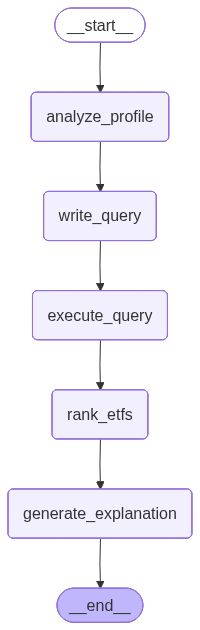

In [66]:
from langgraph.graph import StateGraph, START, END

# 상태 그래프 생성
graph_builder = StateGraph(State)

graph_builder.add_node("analyze_profile", analyze_profile)
graph_builder.add_node("write_query", write_query)
graph_builder.add_node("execute_query", execute_query)
graph_builder.add_node("rank_etfs", rank_etfs)
graph_builder.add_node("generate_explanation", generate_explanation)

graph_builder.add_edge(START, "analyze_profile")
graph_builder.add_edge("analyze_profile", "write_query")
graph_builder.add_edge("write_query", "execute_query")
graph_builder.add_edge("execute_query", "rank_etfs")
graph_builder.add_edge("rank_etfs", "generate_explanation")
graph_builder.add_edge("generate_explanation", END)

graph = graph_builder.compile()


# 상태 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [67]:
# 사용자 질문 예시

test_questions = [
    """
    40대 중반의 직장인입니다. 
    월 200만원 정도를 1년 이상 장기 투자하고 싶고,
    환율과 금리에 관심이 있습니다.
    저위험 안정적인 수익을 추구하며, ESG 요소도 고려하고 싶습니다.
    적합한 ETF를 추천해주세요.
    """,
    """
    20대 후반의 대학생입니다. 
    월 50만원 정도를 1년 이상 장기 투자하고 싶고,
    환율과 금리에 관심이 있습니다.
    고위험 고수익을 추구하며, ESG 요소도 고려하고 싶습니다.
    적합한 ETF를 추천해주세요.
    """,
    """
    32살 맞벌이 부부입니다. 
    둘이 합쳐서 월 200만원을 노후자금으로 굴리고 싶어요. 
    제약/바이오와 클라우드 컴퓨팅 쪽을 보고 있습니다. 
    안정성과 수익성의 균형을 맞추고 싶고, 
    지속가능한 기업들 위주로 투자하고 싶습니다.
    적합한 ETF를 추천해주세요.
    """
]


# 상태 그래프 실행
etf_recommendations = []
for question in test_questions:
    etf_recommendation = graph.invoke(
        {"question": question}
    )
    etf_recommendations.append(etf_recommendation)

In [68]:

Markdown(etf_recommendations[0]["final_answer"]["markdown"])

# ETF 포트폴리오 추천

## 투자 전략 개요
본 포트폴리오는 사용자의 보수적인 위험 성향과 장기 투자 기간, 그리고 안정적인 수익과 환율, 금리, ESG 요소에 대한 관심을 반영하여 구성되었습니다. 추천된 ETF들은 주로 ESG 요소를 반영한 채권형 액티브 펀드로, 금융 시장의 변동성을 낮추면서도 안정적인 수익 창출이 가능합니다. 환율 및 금리 변동에 민감한 해외 채권을 포함해 포트폴리오의 다각화를 도모하였고, 낮은 총보수와 높은 순자산규모를 통한 효율성을 갖추어 장기 투자에 적합합니다.

## 추천 ETF 포트폴리오

| ETF | 종목코드 | 추천비중 |
|-----|----------|----------|
| KODEX ESG종합채권(A-이상)액티브 | 439860 | 40% |
| KODEX 아시아달러채권ESG플러스액티브 | 437070 | 35% |
| KODEX 미국종합채권ESG액티브(H) | 437080 | 25% |

## ETF 상세 설명

### KODEX ESG종합채권(A-이상)액티브 (439860)
ESG 평가 A- 이상 안전등급 채권에 투자하는 액티브 ETF로, 변동성이 낮고 안정적인 수익 추구에 최적화되어 있습니다. 총보수가 낮고 순자산총액이 크며, 국내 채권 시장 기반으로 안정성을 확보합니다.

**주요 투자 포인트:**

* ESG 요소를 고려한 보수적인 채권 투자
* 낮은 변동성으로 안정적 수익 가능
* 총보수가 낮아 장기 투자에 유리
* 국내 채권시장에 근거한 자산 구성

**투자 위험:**

* 채권 금리 변동에 따른 가치 변동 위험
* 신용디폴트 위험은 낮으나 완전 배제 불가
* 시장 전반의 금리 인상시 수익률 저하 가능

### KODEX 아시아달러채권ESG플러스액티브 (437070)
아시아 지역의 달러 표시 채권에 ESG 요소를 적용하여 투자하는 ETF로, 비교적 안정적이며 환율 위험을 감안하여 장기적인 수익을 추구합니다. 총보수가 적당하며, 아시아 시장의 성장 잠재력도 일부 반영합니다.

**주요 투자 포인트:**

* 아시아 지역 달러채권에 투자하여 환율 노출
* ESG 기준이 적용된 발행채권으로 사회책임 투자 강화
* 변동성이 낮고 장기 투자에 적합
* 적당한 총보수로 투자 효율성 확보

**투자 위험:**

* 환율 변동성으로 인한 자산가치 변동 가능성
* 아시아 신흥국의 신용 리스크 및 정치적 위험
* 달러금리 변화에 따른 채권 가격 변동

### KODEX 미국종합채권ESG액티브(H) (437080)
미국 종합 채권에 ESG 투자기준을 적용한 ETF로, 미국 시장의 안정성과 환헤지(Hedged)를 통해 환율 리스크를 감소시켰습니다. 금리 변동에 대응하며 보수적인 수익을 추구합니다.

**주요 투자 포인트:**

* 미국 전체 채권시장에 투자하여 분산효과 극대화
* ESG 기준을 반영한 투자로 지속가능성 확보
* 환헤지 옵션으로 환율 변동 위험 최소화
* 보수적인 투자자에게 적합한 안정성 제공

**투자 위험:**

* 미국 금리 상승 시 채권가격 하락 위험
* 헤지 비용이 발생할 수 있음
* 시장 상황에 따른 유동성 변화 가능성

## 투자 시 고려사항

* 채권 ETF 특성상 금리 상승 시 가격 변동성이 발생할 수 있으므로 금리 추이 모니터링이 필요합니다.
* 환율이 포트폴리오 수익률에 영향을 미치므로 해외채권 환노출 부분에 대한 주기적 점검이 요구됩니다.
* ESG 기준 변화에 따른 자산 구성 변경 가능성 및 이에 따른 투자 성과 변동에 유의해야 합니다.
* 장기 투자에 적합하나, 중간 리밸런싱을 통해 시장 변동성 및 투자 목표 변화를 반영하는 것이 좋습니다.


In [69]:

Markdown(etf_recommendations[1]["final_answer"]["markdown"])

# ETF 포트폴리오 추천

## 투자 전략 개요
사용자는 장기 투자로 고위험 고수익을 추구하며 ESG 요소를 고려하는 투자 성향을 가지고 있습니다. 또한, 환율 및 금리 관련 섹터에 관심이 있고, 월 50만원을 꾸준히 투자하는 계획을 세우고 있습니다. 이에 맞춰, 성장 가능성과 ESG 특성을 고려한 다양한 ETF를 추천하며, 각각의 ETF가 포트폴리오 내에서 위험 분산과 장기 수익 추구에 기여하도록 구성하였습니다.

## 추천 ETF 포트폴리오

| ETF | 종목코드 | 추천비중 |
|-----|----------|----------|
| TIGER SYNTH-NVIDIA UST Cvd Call Balanced | 0000D0 | 50% |
| KODEX 200 | 069500 | 30% |
| KOSEF 200 | 069660 | 20% |

## ETF 상세 설명

### TIGER SYNTH-NVIDIA UST Cvd Call Balanced (0000D0)
이 ETF는 NVIDIA 관련 주식과 미국 국채 옵션을 결합한 복합형 펀드로, 고위험 고수익 전략이며 ESG 요소를 고려한 투자 방식을 채택하고 있습니다. 총보수는 0.39%로 합리적인 수준이며, AUM 또한 약 1,119억원 규모로 안정적입니다.

**주요 투자 포인트:**

* 최근 1년 수익률 4.52%로 양호한 성장세
* ESG 요소를 반영한 투자 전략
* 고위험 고수익 추구에 적합
* 적절한 비용 구조로 장기 투자에 유리

**투자 위험:**

* 시장 변동성에 따른 높은 가격 변동 위험
* 환율 및 금리 변동에 대한 민감성
* 복합형 자산 구성에 따른 복잡성 증가

### KODEX 200 (069500)
KOSPI 200 지수를 추종하는 대표적인 ETF로, 최근 1년간 수익률은 -3.66%로 다소 부진하지만, 낮은 총보수 0.15%와 높은 운용자산규모로 장기적 안정성을 갖추고 있습니다. 전통적인 대형주 중심 투자로 거시경제 및 시장 전반 성장에 대응합니다.

**주요 투자 포인트:**

* 대형주 위주의 안정적 포트폴리오 제공
* 낮은 운용보수 0.15%
* 높은 자산 규모로 유동성 우수
* 시장의 전반적 성장에 베팅 가능

**투자 위험:**

* 시장 전체의 하락 위험 반영
* 거시경제 악화시 변동성 상승 가능

### KOSEF 200 (069660)
KODEX 200과 동일한 KOSPI 200 지수를 추종하며, 총보수는 0.05%로 매우 낮아 비용 효율적인 장기 투자에 적합합니다. AUM도 약 998억원으로 안정적인 수준을 유지하고 있습니다.

**주요 투자 포인트:**

* KOSPI 200 지수 기반 안정적 투자
* 가장 낮은 총보수 0.05%
* 높은 유동성 보유
* 장기 투자 시 비용 절감 효과 큼

**투자 위험:**

* 시장 변동성에 따른 위험 내포
* 거시경제 상황에 따른 주가 변동성

## 투자 시 고려사항

* 장기 투자 기간 동안 시장 변동성에 따른 가격 급변에 대비해야 합니다.
* 고위험 전략을 따르는 TIGER SYNTH-NVIDIA ETF의 변동성을 특히 유념해야 합니다.
* 매월 일정 금액 투자 시 분할 매수 효과로 변동성을 완화할 수 있습니다.
* 포트폴리오 리밸런싱 시점과 방법을 사전에 계획하여 위험관리를 강화하는 것이 필요합니다.
* 환율 및 금리 변동과 관련한 섹터 선호도를 반영하였으나, 외부 경제 요인의 영향에 주의해야 합니다.


In [70]:

Markdown(etf_recommendations[2]["final_answer"]["markdown"])

# ETF 포트폴리오 추천

## 투자 전략 개요
본 투자 포트폴리오는 중간 정도의 위험 수용도를 가진 장기 투자자를 위해 설계되었으며, 사용자의 노후자금 마련이라는 목표에 부합하도록 안정성과 수익성 간의 균형을 추구합니다. 특히 사용자의 선호 섹터인 제약/바이오와 클라우드 컴퓨팅을 반영하는 ETF뿐만 아니라 안정적인 수익원을 제공하는 채권형 ETF도 포함하여 포트폴리오의 다양성과 리스크 분산을 도모했습니다.

## 추천 ETF 포트폴리오

| ETF | 종목코드 | 추천비중 |
|-----|----------|----------|
| KOSEF 미국블록버스터바이오테크의약품+ | 483030 | 50% |
| 1Q 25-08 회사채(A+이상)액티브 | 466400 | 30% |
| 1Q CD금리액티브(합성) | 491610 | 20% |

## ETF 상세 설명

### KOSEF 미국블록버스터바이오테크의약품+ (483030)
이 ETF는 미국 시장의 혁신적인 제약 및 바이오테크 기업에 투자하여 성장 잠재력을 추구합니다. 제약/바이오 섹터에 집중되어 있어 사용자의 선호 투자 섹터를 충족시키며, 상대적으로 낮은 변동성과 안정성을 제공하지만 총보수는 다소 높은 편입니다.

**주요 투자 포인트:**

* 제약/바이오 섹터에 집중 투자
* 사용자의 선호 섹터와 부합
* 성장 잠재력이 높으나 변동성 존재

**투자 위험:**

* 제약/바이오 산업 특유의 규제 및 임상 시험 리스크
* 높은 총보수로 인한 수익률 저하 가능성
* 시장 변동성에 따른 자산가치 변동 위험

### 1Q 25-08 회사채(A+이상)액티브 (466400)
이 ETF는 신용등급 A+ 이상인 회사채에 투자하여 안정적인 수입을 추구하는 채권형 상품입니다. 변동성이 낮아 포트폴리오 내 안정성 강화에 기여하며, 사용자의 보수적인 투자 성향과 장기 투자 목표에 적합합니다.

**주요 투자 포인트:**

* 안정적인 회사채에 투자
* 낮은 변동성과 신용 위험 관리
* 포트폴리오 내 안정성 기여

**투자 위험:**

* 금리 변동에 따른 채권 가격 하락 위험
* 기업 신용등급 하락에 따른 가치 하락 가능성
* 인플레이션 상승 시 실질 수익률 감소

### 1Q CD금리액티브(합성) (491610)
이 ETF는 단기 시장성 예금증서(CD)에 투자하여 상대적으로 안전한 수익을 제공합니다. 매우 낮은 변동성으로 포트폴리오 내 현금성 자산 역할을 하며, 장기 투자시 유동성 확보와 위험 분산에 이점이 있습니다.

**주요 투자 포인트:**

* 단기 CD 투자로 안전성 강조
* 매우 낮은 변동성 및 유동성 우수
* 포트폴리오 내 리스크 완화 역할

**투자 위험:**

* 극히 낮은 수익률
* 인플레이션에 의한 구매력 저하 가능성
* 시장 금리 급변 시 재투자 위험

## 투자 시 고려사항

* 총보수가 높은 ETF는 장기 투자 시 수익률에 영향을 줄 수 있으므로 관리가 필요합니다.
* 채권형 ETF는 금리 변동에 민감하므로 금리 환경 변화를 주기적으로 모니터링해야 합니다.
* 주요 투자 섹터가 편중될 경우 개별 산업 리스크에 노출될 수 있어 필요시 추가 섹터 분산을 고려해야 합니다.
* 정기적인 포트폴리오 리밸런싱을 통해 목표 자산 배분 비율을 유지하는 것이 안정적 수익 확보에 중요합니다.


**테스트 검증**: 추천 결과의 필수 필드 검증 로직 추가

In [76]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

# 1. 검증 결과 스키마 정의
class AnswerValidation(BaseModel):
    is_valid: bool = Field(description="필수 요소가 모두 포함되어 있으면 True, 누락이 있으면 False")
    missing_fields: list[str] = Field(description="누락된 필수 필드 목록 (없으면 빈 리스트)")
    reason: str = Field(description="채점 결과에 대한 간단한 이유 설명")

def validate_recommendation_result(result_state: dict) -> AnswerValidation:
    """최종 생성된 답변에 필수 내용이 모두 들어갔는지 LLM으로 검증합니다."""
    
    user_profile = result_state.get("user_profile", "")
    answer = result_state.get("final_answer", "")
    
    # 채점관 프롬프트 작성
    validation_prompt = (
        "당신은 금융 인공지능의 답변을 평가하는 깐깐한 품질 검사관입니다.\n"
        "최종 생성된 답변(Answer)이 아래의 필수 조건(필드)을 모두 충족하는지 검증하세요.\n\n"
        "[필수 필드 조건]\n"
        "1. 구체적인 ETF 종목명 또는 티커(Ticker)가 언급되었는가?\n"
        "2. 사용자의 투자 성향(예: 안정형, 공격형 등)에 매칭되는 근거가 설명되었는가?\n"
        "3. 투자 금액이나 기간(예: 장기 투자 등)에 대한 언급이 포함되었는가?\n\n"
        f"[유저 프로필]: {user_profile}\n"
        f"[최종 답변(Markdown)]:\n{answer}\n"
    )
    
    # 구조화된 출력(Structured Output) 활용
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    evaluator = llm.with_structured_output(AnswerValidation)
    
    return evaluator.invoke(validation_prompt)

# --- 실행 및 검증 예시 ---
validation_report = validate_recommendation_result(etf_recommendations[2])

print(f"✅ 검증 통과 여부: {validation_report.is_valid}")
print(f"❌ 누락된 필드: {validation_report.missing_fields}")
print(f"📝 상세 사유: {validation_report.reason}")

✅ 검증 통과 여부: True
❌ 누락된 필드: []
📝 상세 사유: 


In [77]:
from langchain_core.documents import Document

# Few-Shot 예시 데이터셋
examples = [
    {"question": "ETF 총 개수는?", "sql": "SELECT COUNT(*) FROM ETFs", "category": "count"},
    {"question": "총보수가 0.1% 이하인 ETF는?", "sql": "SELECT 종목명, 총보수 FROM ETFs WHERE 총보수 <= 0.1 ORDER BY 총보수 ASC LIMIT 10", "category": "filter"},
    {"question": "순자산총액이 가장 큰 ETF는?", "sql": "SELECT 종목명, 순자산총액 FROM ETFs ORDER BY 순자산총액 DESC LIMIT 1", "category": "sort"},
    {"question": "운용사별 ETF 개수는?", "sql": "SELECT 운용사, COUNT(*) as cnt FROM ETFs GROUP BY 운용사 ORDER BY cnt DESC LIMIT 10", "category": "aggregation"},
    {"question": "평균 수익률이 가장 높은 분류체계는?", "sql": "SELECT 분류체계, AVG(수익률_최근1년) as avg_ret FROM ETFs GROUP BY 분류체계 ORDER BY avg_ret DESC LIMIT 5", "category": "aggregation"},
    {"question": "운용사별 평균 총보수를 비교해주세요", "sql": "SELECT 운용사, AVG(총보수) as avg_fee FROM ETFs GROUP BY 운용사 ORDER BY avg_fee ASC LIMIT 10", "category": "aggregation"},
    {"question": "KB자산운용의 ETF 중 수익률 상위 5개는?", "sql": "SELECT 종목명, 수익률_최근1년 FROM ETFs WHERE 운용사 = 'KB자산운용' ORDER BY 수익률_최근1년 DESC LIMIT 5", "category": "filter_sort"},
    {"question": "삼성자산운용의 ETF 수는?", "sql": "SELECT COUNT(*) FROM ETFs WHERE 운용사 = '삼성자산운용'", "category": "filter_count"},
    {"question": "순자산 1000억 이상이고 총보수 0.3% 이하인 ETF는?", "sql": "SELECT 종목명, 순자산총액, 총보수 FROM ETFs WHERE 순자산총액 >= 100000000000 AND 총보수 <= 0.3 ORDER BY 순자산총액 DESC LIMIT 10", "category": "complex"},
    {"question": "수익률이 양수이고 변동성이 낮은 ETF를 추천해주세요", "sql": "SELECT 종목명, 수익률_최근1년, 변동성 FROM ETFs WHERE 수익률_최근1년 > 0 AND 변동성 = '매우낮음' ORDER BY 수익률_최근1년 DESC LIMIT 10", "category": "complex"},
    {"question": "분류체계별 ETF 개수를 비교해주세요", "sql": "SELECT 분류체계, COUNT(*) as cnt FROM ETFs GROUP BY 분류체계 ORDER BY cnt DESC", "category": "comparison"},
    {"question": "복제방법별 평균 추적오차는?", "sql": "SELECT 복제방법, AVG(추적오차) as avg_error FROM ETFs GROUP BY 복제방법 ORDER BY avg_error ASC", "category": "comparison"},
    {"question": "수익률 상위 10% ETF의 평균 총보수는?", "sql": "SELECT AVG(총보수) as avg_fee FROM (SELECT 총보수 FROM ETFs ORDER BY 수익률_최근1년 DESC LIMIT (SELECT COUNT(*) / 10 FROM ETFs))", "category": "advanced"},
]

# 벡터 스토어에 저장
example_docs = [
    Document(page_content=ex["question"], metadata={"sql": ex["sql"], "category": ex["category"]})
    for ex in examples
]
example_store = InMemoryVectorStore(embeddings)
_ = example_store.add_documents(example_docs)
example_retriever = example_store.as_retriever(search_kwargs={"k": 3})

print(f"Few-Shot 예시 벡터 스토어 구축 완료: {len(example_docs)}개")

Few-Shot 예시 벡터 스토어 구축 완료: 13개


In [78]:
def format_examples(docs):
    """검색된 예시를 프롬프트 형식으로 변환"""
    formatted = []
    for doc in docs:
        formatted.append(
            f"Question: {doc.page_content}\n"
            f"SQL: {doc.metadata['sql']}"
        )
    return "\n\n".join(formatted)

# Few-Shot 프롬프트 템플릿
fewshot_prompt_template = ChatPromptTemplate.from_template("""
Given an input question, create a syntactically correct {dialect} query to run to help find the answer.
Unless the user specifies a specific number, always limit to at most {top_k} results.
Order by relevant columns. Only ask for relevant columns.
Pay attention to column names in the schema.

Only use the following tables:
{table_info}

Entity names to consider:
{entity_info}

Here are some similar examples for reference:

{examples}

Now generate the SQL for this question:
Question: {input}
""")

In [79]:
from pydantic import BaseModel, Field
from typing import Literal

class DecomposedQuestions(BaseModel):
    """질문 분해 결과"""
    is_complex: bool = Field(description="분해가 필요한 복잡한 질문인지 여부")
    reasoning: str = Field(description="복잡도 판단 근거")
    sub_questions: List[str] = Field(
        description="분해된 서브 질문들 (단순 질문이면 원래 질문 1개)"
    )
    aggregation_strategy: Literal["compare", "aggregate", "sequential"] = Field(
        description=(
            "결과 종합 방법: "
            "compare(서로 다른 조건의 결과 비교), "
            "aggregate(여러 집계 종합), "
            "sequential(이전 결과를 다음 조건으로 사용)"
        )
    )

decompose_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 데이터베이스 질문 분석 전문가입니다.
사용자의 질문이 단일 SQL로 처리할 수 있는지 판단하고,
복잡한 경우 서브 질문으로 분해하세요.

## 분해 기준
- 2개 이상의 **독립적인 조건/그룹**의 결과를 비교하는 경우 → 분해 (compare)
- 여러 **서로 다른 집계**(평균, 개수, 최대 등)를 동시에 구하는 경우 → 분해 (aggregate)
- 한 쿼리의 **결과를 다른 쿼리의 조건**으로 사용하는 경우 → 분해 (sequential)
- 단순 조회, 단일 집계, 단일 필터 → 분해 불필요

## 분해 불필요 예시
- "ETF 총 개수는?" → 단순 COUNT
- "KB자산운용의 ETF 중 수익률 상위 5개는?" → 단일 WHERE + ORDER BY
- "운용사별 평균 총보수는?" → 단일 GROUP BY

## 분해 필요 예시
- "A와 B를 비교해주세요" → compare: [A의 정보?, B의 정보?]
- "가장 X인 Y의 Z는?" → sequential: [가장 X인 Y는?, Y의 Z는?]

## 주의사항
- 서브 질문은 **각각 독립적으로 SQL 쿼리가 가능**하도록 구체적으로 작성
- sequential의 경우 후속 질문에 선행 질문의 결과를 참조하는 표현 포함

데이터베이스 스키마:
{schema}"""),
    ("user", "질문: {question}")
])

decomposer = llm.with_structured_output(DecomposedQuestions)

In [80]:
class DecompState(TypedDict):
    question: str
    is_complex: bool
    sub_questions: list
    aggregation_strategy: str
    sub_results: list
    query: str       # 단순 질문용
    result: str      # 단순 질문용
    answer: str

def decompose_question(state: DecompState):
    """질문 복잡도 분석 및 분해"""
    result = decomposer.invoke(
        decompose_prompt.invoke({
            "schema": db.get_table_info(),
            "question": state["question"]
        })
    )
    
    if not result.is_complex:
        print(f"  단순 질문 -> 분해 없이 처리")
        return {
            "is_complex": False,
            "sub_questions": [state["question"]],
            "aggregation_strategy": "sequential"
        }
    
    print(f"  복잡한 질문 -> {len(result.sub_questions)}개 서브 질문으로 분해")
    print(f"  전략: {result.aggregation_strategy}")
    for i, sq in enumerate(result.sub_questions, 1):
        print(f"     {i}. {sq}")
    
    return {
        "is_complex": True,
        "sub_questions": result.sub_questions,
        "aggregation_strategy": result.aggregation_strategy
    }

def execute_sub_questions(state: DecompState):
    """각 서브 질문에 대해 Few-Shot SQL 생성 및 실행"""
    sub_results = []
    tool = QuerySQLDatabaseTool(db=db)
    
    for i, sq in enumerate(state["sub_questions"], 1):
        print(f"\n  서브 질문 {i}: {sq}")
        
        # Few-Shot 예시 검색
        similar_docs = example_retriever.invoke(sq)
        formatted = format_examples(similar_docs)
        
        # SQL 생성 (Few-Shot + Entity Matching)
        prompt = fewshot_prompt_template.invoke({
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "entity_info": entity_retriever_tool.invoke(sq),
            "examples": formatted,
            "input": sq,
        })
        structured_llm = llm.with_structured_output(QueryOutput)
        query_result = structured_llm.invoke(prompt)
        sql = query_result["query"]
        
        # SQL 실행
        try:
            result = tool.invoke(sql)
        except Exception as e:
            result = f"오류: {str(e)}"
        
        sub_results.append({
            "question": sq,
            "sql": sql,
            "result": result
        })
        print(f"     SQL: {sql[:100]}")
        print(f"     결과: {str(result)[:120]}")
    
    return {"sub_results": sub_results}

def synthesize_results(state: DecompState):
    """서브 결과를 종합하여 최종 답변 생성"""
    sub_info = ""
    for i, sr in enumerate(state["sub_results"], 1):
        sub_info += (
            f"\n--- 서브 질문 {i} ---\n"
            f"질문: {sr['question']}\n"
            f"SQL: {sr['sql']}\n"
            f"결과: {sr['result']}\n"
        )
    
    strategy = state.get("aggregation_strategy", "sequential")
    
    synthesis_prompt = f"""사용자의 원래 질문에 대해 완전한 답변을 생성하세요.

원래 질문: {state['question']}
종합 전략: {strategy}

각 서브 질문의 실행 결과:
{sub_info}

## 종합 가이드라인
- compare: 두 결과를 나란히 비교하여 차이점을 명확히 설명
- aggregate: 여러 집계 결과를 통합하여 종합적인 분석 제공
- sequential: 순차적 결과를 연결하여 논리적 흐름으로 답변

한국어로 명확하고 구체적으로 답변하세요."""
    
    response = llm.invoke(synthesis_prompt)
    return {"answer": response.content}

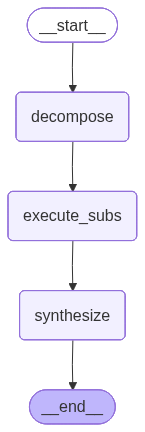

In [87]:
# Decomposition 그래프
decomp_graph = StateGraph(DecompState)

decomp_graph.add_node("decompose", decompose_question)
decomp_graph.add_node("execute_subs", execute_sub_questions)
decomp_graph.add_node("synthesize", synthesize_results)

decomp_graph.add_edge(START, "decompose")
decomp_graph.add_edge("decompose", "execute_subs")
decomp_graph.add_edge("execute_subs", "synthesize")
decomp_graph.add_edge("synthesize", END)

decomp_chain = decomp_graph.compile()

display(Image(decomp_chain.get_graph().draw_mermaid_png()))

In [81]:
def route_by_complexity(state: DecompState) -> str:
    """복잡도에 따라 처리 경로 선택"""
    if state.get("is_complex", False):
        return "execute_subs"
    return "simple_query"

def simple_query(state: DecompState):
    """단순 질문: Few-Shot SQL 생성 + 실행"""
    similar_docs = example_retriever.invoke(state["question"])
    formatted = format_examples(similar_docs)
    
    prompt = fewshot_prompt_template.invoke({
        "dialect": db.dialect,
        "top_k": 10,
        "table_info": db.get_table_info(),
        "entity_info": entity_retriever_tool.invoke(state["question"]),
        "examples": formatted,
        "input": state["question"],
        
    })
    structured_llm = llm.with_structured_output(QueryOutput)
    query_result = structured_llm.invoke(prompt)
    
    tool = QuerySQLDatabaseTool(db=db)
    try:
        result = tool.invoke(query_result["query"])
    except Exception as e:
        result = f"오류: {str(e)}"
    
    return {"query": query_result["query"], "result": result}

def generate_simple_answer(state: DecompState):
    """단순 질문 답변 생성"""
    prompt = (
        "Given the following user question, corresponding SQL query, "
        "and SQL result, answer the user question.\n\n"
        f'Question: {state["question"]}\n'
        f'SQL Query: {state["query"]}\n'
        f'SQL Result: {state["result"]}'
    )
    response = llm.invoke(prompt)
    return {"answer": response.content}
    

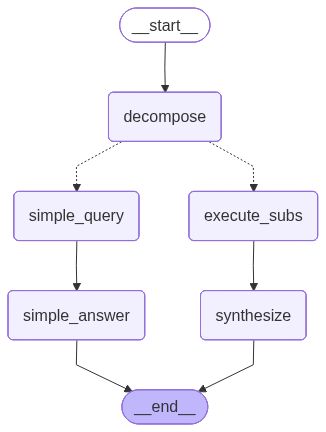

In [82]:
# 통합 그래프
integrated_graph = StateGraph(DecompState)

integrated_graph.add_node("decompose", decompose_question)
integrated_graph.add_node("simple_query", simple_query)
integrated_graph.add_node("execute_subs", execute_sub_questions)
integrated_graph.add_node("simple_answer", generate_simple_answer)
integrated_graph.add_node("synthesize", synthesize_results)

# 엣지 연결
integrated_graph.add_edge(START, "decompose")
integrated_graph.add_conditional_edges(
    "decompose", 
    route_by_complexity,
      {
        "execute_subs": "execute_subs",
        "simple_query": "simple_query"
    } )
integrated_graph.add_edge("simple_query", "simple_answer")
integrated_graph.add_edge("execute_subs", "synthesize")
integrated_graph.add_edge("simple_answer", END)
integrated_graph.add_edge("synthesize", END)

integrated_chain = integrated_graph.compile()

display(Image(integrated_chain.get_graph().draw_mermaid_png()))

In [99]:
# 통합 파이프라인 테스트 (일반 텍스트 출력 버전)
for q in test_questions:
    print("=" * 60)
    print(f"👉 입력 질문:\n{q.strip()}")
    print("=" * 60)
    
    # 루프 변수 q를 정확히 전달하여 그래프 호출
    result = graph.invoke({"question": q})
    
    print("\n[답변 내용]")
    
    # final_answer 구조 안에 있는 마크다운 텍스트 원문을 그대로 꺼내서 print로 출력합니다.
    if "final_answer" in result and "markdown" in result["final_answer"]:
        print(result["final_answer"]["markdown"])
        
    elif "answer" in result:
        # 혹시 answer 서랍 안에 들어있는 경우를 위한 방어용 코드
        if isinstance(result["answer"], dict) and "markdown" in result["answer"]:
            print(result["answer"]["markdown"])
        else:
            print(result["answer"])
    else:
        print("결과 데이터를 찾을 수 없습니다. 키 구조를 확인해 보세요.")
        
    print("\n" + "=" * 60 + "\n")

👉 입력 질문:
40대 중반의 직장인입니다. 
    월 200만원 정도를 1년 이상 장기 투자하고 싶고,
    환율과 금리에 관심이 있습니다.
    저위험 안정적인 수익을 추구하며, ESG 요소도 고려하고 싶습니다.
    적합한 ETF를 추천해주세요.

[답변 내용]
40대 중반의 직장인님께서 월 200만원 정도를 1년 이상 장기 투자하시며, 환율과 금리에 관심이 있고, 저위험 안정적인 수익과 ESG 요소도 고려하는 점을 반영하여 다음과 같이 추천드립니다.

아래는 변동성이 매우 낮고, ESG 요소를 포함한 채권형 ETF 중 수익률이 좋은 상위 4종목입니다.

1. **KODEX 아시아달러채권ESG플러스액티브 (종목코드: 437070)**  
   - 최근 1년 수익률: 16.31%  
   - 변동성: 매우 낮음  
   - 순자산총액: 약 625억 원  
   - 특징: 아시아 달러채권에 투자하며 ESG 요소를 고려한 상품으로, 환율과 금리 변화 반영 가능성이 큽니다.  

2. **KODEX ESG종합채권(A-이상)액티브 (종목코드: 439860)**  
   - 최근 1년 수익률: 5.44%  
   - 변동성: 매우 낮음  
   - 순자산총액: 약 2,914억 원  
   - 특징: 등급 A- 이상 기업채권 중심으로 ESG 기준을 적용해 안정적인 수익 추구.  

3. **히어로즈 단기채권ESG액티브 (종목코드: 419890)**  
   - 최근 1년 수익률: 4.46%  
   - 변동성: 매우 낮음  
   - 순자산총액: 약 911억 원  
   - 특징: 단기 채권 위주로 구성되어 안정성과 유동성을 높인 ESG 채권형 ETF입니다.  

4. **KODEX 미국종합채권ESG액티브(H) (종목코드: 437080)**  
   - 최근 1년 수익률: 1.83%  
   - 변동성: 매우 낮음  
   - 순자산총액: 약 1,141억 원  
   - 특징: 미국 종합 채권에 투자하며 ESG 기준을 충족하는 상품으로 환율 영향도 다소 반영됨

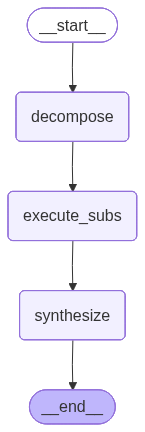

In [89]:
# [예시 정답] Sequential Decomposition 개선
#
# 핵심: sequential 전략일 때 이전 서브 질문의 결과를
# 다음 서브 질문의 컨텍스트로 전달하여 정확도 향상

def execute_sub_questions_sequential(state: DecompState):
    """
    서브 질문 실행 (sequential 전략 개선 버전)
    - compare/aggregate: 기존과 동일하게 독립 실행
    - sequential: 이전 서브 질문의 결과를 다음 서브 질문에 반영
    """
    sub_results = []
    tool = QuerySQLDatabaseTool(db=db)
    strategy = state.get("aggregation_strategy", "sequential")
    
    for i, sq in enumerate(state["sub_questions"]):
        # sequential 전략이고 첫 번째 서브 질문이 아닌 경우
        # → 이전 결과를 현재 질문에 컨텍스트로 추가
        if strategy == "sequential" and i > 0:
            prev = sub_results[i - 1]
            sq_with_context = (
                f"{sq}\n"
                f"(참고: 이전 단계 질문 '{prev['question']}'의 결과 = {prev['result']})"
            )
            print(f"\n  서브 질문 {i+1} (이전 결과 반영): {sq}")
        else:
            sq_with_context = sq
            print(f"\n  서브 질문 {i+1}: {sq}")
        
        # Few-Shot 예시 검색 (원래 질문으로 검색하여 관련 예시 확보)
        similar_docs = example_retriever.invoke(sq)
        formatted = format_examples(similar_docs)
        
        # SQL 생성 (컨텍스트가 포함된 질문 사용)
        prompt = fewshot_prompt_template.invoke({
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "entity_info": entity_retriever_tool.invoke(sq),
            "examples": formatted,
            "input": sq_with_context,  # 이전 결과가 포함된 질문
        })
        structured_llm = llm.with_structured_output(QueryOutput)
        query_result = structured_llm.invoke(prompt)
        sql = query_result["query"]
        
        # SQL 실행
        try:
            result = tool.invoke(sql)
        except Exception as e:
            result = f"오류: {str(e)}"
        
        sub_results.append({
            "question": sq,
            "sql": sql,
            "result": result
        })
        print(f"     SQL: {sql[:100]}")
        print(f"     결과: {str(result)[:120]}")
    
    return {"sub_results": sub_results}


# 개선된 Decomposition 그래프 구성
improved_graph = StateGraph(DecompState)

improved_graph.add_node("decompose", decompose_question)
improved_graph.add_node("execute_subs", execute_sub_questions_sequential)  # 개선된 버전
improved_graph.add_node("synthesize", synthesize_results)

improved_graph.add_edge(START, "decompose")
improved_graph.add_edge("decompose", "execute_subs")
improved_graph.add_edge("execute_subs", "synthesize")
improved_graph.add_edge("synthesize", END)

improved_chain = improved_graph.compile()

display(Image(improved_chain.get_graph().draw_mermaid_png()))

In [92]:
for q in test_questions:
    print("=" * 70)
    print(f"Q: {q}")
    print("=" * 70)
    
    # 기존 방식 (독립 실행)
    print("\n[기존 - 독립 실행]")
    result_old = decomp_chain.invoke({"question": q})
    for sr in result_old.get("sub_results", []):
        print(f"  서브: {sr['question'][:50]}")
        print(f"  SQL: {sr['sql'][:80]}")
    print(f"  답변: {result_old['answer']}...")
    
    # 개선 방식 (이전 결과 반영)
    print("\n[개선 - 이전 결과 반영]")
    result_new = improved_chain.invoke({"question": q})
    for sr in result_new.get("sub_results", []):
        print(f"  서브: {sr['question'][:50]}")
        print(f"  SQL: {sr['sql'][:80]}")
    print(f"  답변: {result_new['answer']}...")
    print()

Q: 
    40대 중반의 직장인입니다. 
    월 200만원 정도를 1년 이상 장기 투자하고 싶고,
    환율과 금리에 관심이 있습니다.
    저위험 안정적인 수익을 추구하며, ESG 요소도 고려하고 싶습니다.
    적합한 ETF를 추천해주세요.
    

[기존 - 독립 실행]
  복잡한 질문 -> 3개 서브 질문으로 분해
  전략: sequential
     1. 1. 저위험 안정적인 수익을 추구하는 ETF 목록을 조회해주세요.
     2. 2. 1번에서 조회된 ETF 중 환율이나 금리와 관련된 ETF를 필터링해주세요.
     3. 3. 2번에서 조회된 ETF 중 ESG 요소를 고려한 ETF를 선별해주세요.

  서브 질문 1: 1. 저위험 안정적인 수익을 추구하는 ETF 목록을 조회해주세요.
     SQL: SELECT 종목명, 수익률_최근1년, 변동성, 추적오차 FROM ETFs WHERE 변동성 IN ('매우낮음', '낮음') ORDER BY 수익률_최근1년 DESC LIMIT 1
     결과: [('KODEX 미국S&P500TR', 44.02, '낮음', 0.12), ('KOSEF 미국S&P500', 42.78, '낮음', 0.55), ('WON 미국S&P500', 42.4, '낮음', 0.44), ('S

  서브 질문 2: 2. 1번에서 조회된 ETF 중 환율이나 금리와 관련된 ETF를 필터링해주세요.
     SQL: SELECT 종목명, 분류체계, 운용사, 수익률_최근1년, 기초지수, 총보수 FROM ETFs WHERE (분류체계 LIKE '%금리%' OR 분류체계 LIKE '%환율%') OR
     결과: 

  서브 질문 3: 3. 2번에서 조회된 ETF 중 ESG 요소를 고려한 ETF를 선별해주세요.
     SQL: SELECT e.종목코드, e.종목명, e.수익률_최근1년, e.변동성, e.총보수 FROM ETFs e JOIN ETFsInfo ei ON e.종목코드 = ei.종목코드 WHER
     결과: [(